In [ ]:
pip install linearmodels

In [ ]:
pip install statsmodels pandas python-docx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ardl import ARDL, ardl_select_order
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PooledOLS
from statsmodels.tsa.stattools import adfuller
from IPython.display import display # Import display

import warnings
from statsmodels.tools.sm_exceptions import SingularMatrixWarning
warnings.simplefilter('ignore', SingularMatrixWarning)

In [ ]:
# import module to access the drive
from google.colab import drive
drive.mount('/content/drive')

file_path5 = '/content/drive/MyDrive/research/graph bull bear.xlsx'
raw_data = pd.read_excel(file_path5, index_col = 0).dropna()
# sorting it chronologically in order to match the EViews results
raw_data.name = "raw data"

file_path6 = '/content/drive/MyDrive/research/liquidity measure & control sheet.xlsx'
liq_mes_raw = pd.read_excel(file_path6, index_col = 0).dropna()
# sorting it chronologically in order to match the EViews results
liq_mes_raw.name = "liquidity measure & control sheet"

# excel sheet derived from liq mes raw, already sorted to match EViews
file_path7 = '/content/drive/MyDrive/research/df liq mes full.xlsx'
df_liq_mesfull = pd.read_excel(file_path7) # dropna()
df_liq_mesfull.name = "tranformed liquidity measure & control sheet"
df_liq_mesfull


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Date,Bid-Ask,Amihud,Share Turnover,ln(Volume Traded),Rand-Dollar,ln(Market Cap),Regime_Name,Regime_Dummy
0,2016-01-05,-0.282652,7.303286e-11,0.136612,18.787752,15.6087,32.902788,Bull,1
1,2016-01-06,-0.365221,1.119699e-10,0.083846,19.069574,15.7759,32.898582,Bull,1
2,2016-01-07,-0.277819,3.356497e-12,0.058412,19.588500,16.0472,32.887036,Bull,1
3,2016-01-08,-0.246755,2.197022e-11,0.041781,19.140172,16.0307,32.892794,Bull,1
4,2016-01-11,-0.241707,5.546337e-12,0.058700,19.427993,16.6024,32.905862,Bull,1
...,...,...,...,...,...,...,...,...,...
2492,2025-12-29,-0.147648,4.030720e-11,0.194449,18.385300,16.7049,31.963499,Bull,1
2493,2025-12-30,-0.162918,5.943934e-11,0.173800,18.391816,16.6592,31.958977,Bull,1
2494,2025-12-31,-0.131993,3.235049e-11,0.130332,18.051819,16.5980,31.957897,Bull,1
2495,2026-01-02,-0.192023,4.313008e-11,0.204060,18.396216,16.5350,31.979095,Bull,1


In [ ]:
# @title
# 1. CORE TURNING POINT ALGORITHM

def get_initial_extrema(series): #Step 1: Identify initial local maxima and minima across raw series
    peaks, troughs = [], []
    n = len(series)
    for t in range(1, n - 1):
        if series.iloc[t-1] < series.iloc[t] > series.iloc[t+1]:
            peaks.append(t)
        elif series.iloc[t-1] > series.iloc[t] < series.iloc[t+1]:
            troughs.append(t)
    return peaks, troughs

#Step 2: Select peaks that are local max among peaks, and troughs that are local min among troughs

#Step 3: Enforce alternation — remove the lower of two adjacent peaks or the higher of two adjacent troughs
def filter_and_alternate_extrema(series, peaks, troughs):
    # Filter peaks
    valid_peaks = []
    for i in range(len(peaks)):
        prev_val = series.iloc[peaks[i-1]] if i > 0 else -np.inf
        next_val = series.iloc[peaks[i+1]] if i < len(peaks) - 1 else -np.inf
        curr_val = series.iloc[peaks[i]]
        if curr_val > prev_val and curr_val > next_val:
            valid_peaks.append(peaks[i])

    # Filter troughs
    valid_troughs = []
    for j in range(len(troughs)):
        prev_val = series.iloc[troughs[j-1]] if j > 0 else np.inf
        next_val = series.iloc[troughs[j+1]] if j < len(troughs) - 1 else np.inf
        curr_val = series.iloc[troughs[j]]
        if curr_val < prev_val and curr_val < next_val:
            valid_troughs.append(troughs[j])

    # Combine turning points chronologically
    tps = [{'idx': idx, 'type': 'P', 'val': series.iloc[idx]} for idx in valid_peaks] + \
          [{'idx': idx, 'type': 'T', 'val': series.iloc[idx]} for idx in valid_troughs]
    tps = sorted(tps, key=lambda x: x['idx'])

    # Enforce alternation
    alternating = []
    for tp in tps:
        if not alternating:
            alternating.append(tp)
        else:
            last = alternating[-1]
            if last['type'] == tp['type']:
                # Two consecutive peaks: retain higher peak
                if tp['type'] == 'P' and tp['val'] > last['val']:
                    alternating[-1] = tp

                # Two consecutive troughs: retain lower trough
                elif tp['type'] == 'T' and tp['val'] < last['val']:
                    alternating[-1] = tp
            else:
                alternating.append(tp)

    new_peaks = [tp['idx'] for tp in alternating if tp['type'] == 'P']
    new_troughs = [tp['idx'] for tp in alternating if tp['type'] == 'T']

    return new_peaks, new_troughs


# Step 4: Iterate refinement steps to eliminate short-term noise
def identify_market_regimes(series, num_iterations=2):
    peaks, troughs = get_initial_extrema(series)
    for i in range(num_iterations):
        peaks, troughs = filter_and_alternate_extrema(series, peaks, troughs)
    # Construct binary dummy indicator (1 = Bull, 0 = Bear)
    regime = np.full(len(series), np.nan)
    turning_points = sorted([{'idx': idx, 'type': 'P'} for idx in peaks] + [{'idx': idx, 'type': 'T'} for idx in troughs], key = lambda x: x['idx'])

    if turning_points:
        # Pre-first turning point
        regime[:turning_points[0]['idx'] + 1] = 0 if turning_points[0]['type'] == 'P' else 1

        # Between turning points
        for k in range(len(turning_points) - 1):
            start_tp, end_tp = turning_points[k], turning_points[k+1]
            regime[start_tp['idx']:end_tp['idx'] + 1] = 1 if start_tp['type'] == 'P' else 0

        # Post-last turning point
        regime[turning_points[-1]['idx']:] = 1 if turning_points[-1]['type'] == 'P' else 0
    return regime, peaks, troughs

# 2. EXECUTION ON SPREADSHEET
# Load and prepare raw data
# raw_data is already loaded and has 'Date' as its index.

# Create a copy and reset the index to make 'Date' a column and get a default integer index.
df_for_regime_analysis = raw_data.reset_index()

# Ensure 'Date' column is datetime type (it likely already is from read_excel(index_col=0))
df_for_regime_analysis['Date'] = pd.to_datetime(df_for_regime_analysis['Date'])

# Sort by Date to ensure chronological order for the turning point algorithm
# reset_index(drop=True) is used to get a clean integer index after sorting
df_for_regime_analysis = df_for_regime_analysis.sort_values('Date').reset_index(drop=True)

# Generate regime dummy variable (2 passes recommended for major economic cycles)
df_for_regime_analysis['Regime'], peaks, troughs = identify_market_regimes(df_for_regime_analysis['Close'], num_iterations=2)

# Display summary statistics
print(f"Total Bull Days (1): {(df_for_regime_analysis['Regime'] == 1).sum()}")
print(f"Total Bear Days (0): {(df_for_regime_analysis['Regime'] == 0).sum()}")

# Save updated dataset with binary regime column for econometric modeling
#df_for_regime_analysis.to_csv('data_with_regimes.csv', index=False)


Total Bull Days (1): 1137
Total Bear Days (0): 1361


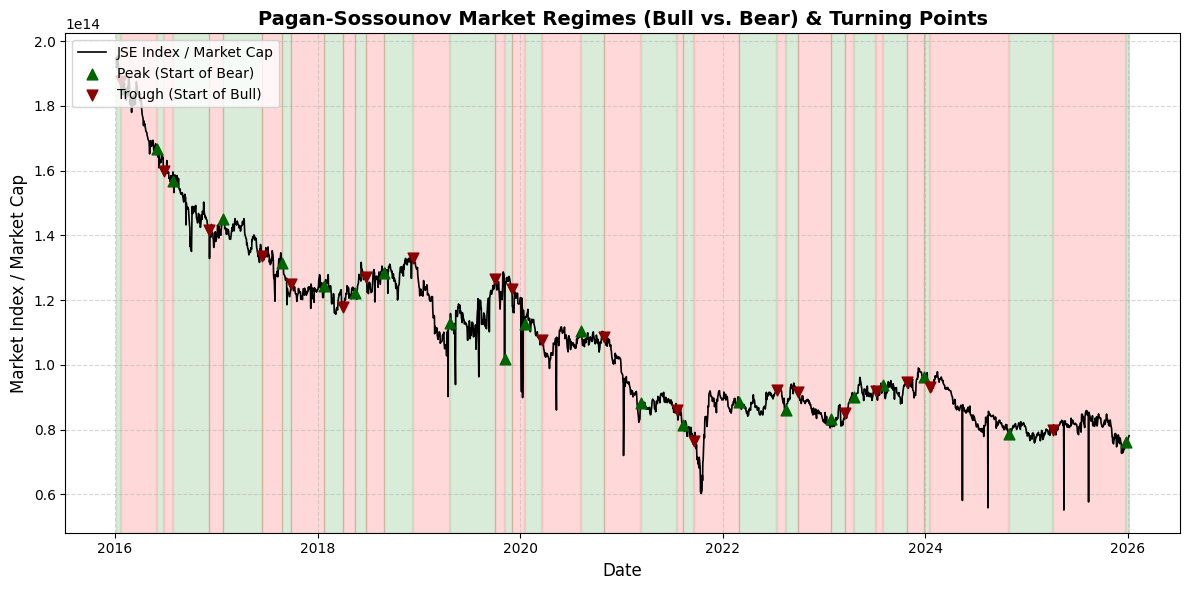

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df_mega = liq_mes_raw.reset_index() # Reset index to make 'Date' a column
file_path1 = '/content/drive/MyDrive/research/market_regime_date_ranges.xlsx'
df_reg = pd.read_excel(file_path1, index_col = 0).reset_index().dropna()
file_path2 = '/content/drive/MyDrive/research/turning_point_dates.xlsx'
df_tp = pd.read_excel(file_path2, index_col = 0).reset_index().dropna()

# 2. Format dates
df_mega = df_mega.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
df_mega['Date'] = pd.to_datetime(df_mega['Date'])
df_reg['Start_Date'] = pd.to_datetime(df_reg['Start_Date'])
df_reg['End_Date'] = pd.to_datetime(df_reg['End_Date'])
df_tp['Date'] = pd.to_datetime(df_tp['Date'])

# 3. Create plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot market price / market cap line
ax.plot(df_mega['Date'], df_mega['Market Cap'], color='black', linewidth=1.2, label='JSE Index / Market Cap')

# Add shaded regime background (Green = Bull, Red = Bear)
for _, row in df_reg.iterrows():
    color = 'green' if row['Regime'] == 'Bull' else 'red'
    ax.axvspan(row['Start_Date'], row['End_Date'], color=color, alpha=0.15)

# Separate peaks and troughs
peaks = df_tp[df_tp['Turning_Point'].str.contains('Peak', na=False)]
troughs = df_tp[df_tp['Turning_Point'].str.contains('Trough', na=False)]

# Merge to get exact market cap/price values at turning points
peaks_merged = pd.merge(peaks, df_mega[['Date', 'Market Cap']], on='Date', how='inner')
troughs_merged = pd.merge(troughs, df_mega[['Date', 'Market Cap']], on='Date', how='inner')

# Plot peak and trough markers
ax.scatter(peaks_merged['Date'], peaks_merged['Market Cap'], color='darkgreen', marker='^', s=60, zorder=5, label='Peak (Start of Bear)')
ax.scatter(troughs_merged['Date'], troughs_merged['Market Cap'], color='darkred', marker='v', s=60, zorder=5, label='Trough (Start of Bull)')

# Formatting details
ax.set_title('Pagan-Sossounov Market Regimes (Bull vs. Bear) & Turning Points', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Market Index / Market Cap', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# descriptive statistics

des = df_liq_mesfull.describe()
des = des.drop(columns = 'Date') # don't run again in same session
des

,Bid-Ask,Amihud,Share Turnover,ln(Volume Traded),Rand-Dollar,ln(Market Cap),Regime_Dummy
count,2497.000000,2.497000e+03,2497.000000,2497.000000,2497.000000,2497.000000,2497.000000
mean,-0.208064,3.191805e-11,0.168334,19.348226,15.800312,32.280476,0.454946
min,-1.540010,8.102832e-15,0.017835,17.187167,11.560400,31.641865,0.000000
25%,-0.242527,1.053203e-11,0.130537,19.165513,14.206900,32.090083,0.000000
50%,-0.182259,2.272656e-11,0.154685,19.328637,15.318500,32.213477,0.000000
75%,-0.143731,4.292753e-11,0.180930,19.484698,17.749300,32.451704,1.000000
max,-0.052914,4.141471e-10,1.217386,21.418539,19.861800,32.905862,1.000000
std,0.104798,3.348766e-11,0.075795,0.355770,2.044389,0.230857,0.498066


In [ ]:
# code from geeksforgeeks: https://www.geeksforgeeks.org/python/unit-root-test/
# and Gemini.ai
# https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html#statsmodels.tsa.stattools.adfuller

# UNIT ROOT FUNCTION

from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
from IPython.display import display # Import display

import warnings
from statsmodels.tools.sm_exceptions import SingularMatrixWarning
warnings.simplefilter('ignore', SingularMatrixWarning)

def adfuller_test_corrected(dataframe, alpha=0.01):
    results_summary = []

    for col in dataframe.select_dtypes(include=[np.number]).columns:
        series = dataframe[col].dropna()

        # Check if series is constant or too short for ADF test
        if series.nunique() <= 1 or len(series) < 2:
            results_summary.append({
                'Variable': col,
                'Order': 'N/A',
                'Level ADF': 'Constant/Too Short',
                'Level p-val': 'N/A',
                'Diff ADF': 'N/A',
                'Diff p-val': 'N/A',
                'Status': 'Cannot test: Series is constant or too short'
            })
            continue # Skip to next column

        # 1. Test Level Series
        # Explicitly set result_object=False to silence FutureWarning and use tuple return
        adf_level = adfuller(series, regression='c', autolag='BIC', result_object=False)
        p_val_level = adf_level[1] # Access p-value from tuple

        if p_val_level <= alpha:
            results_summary.append({
                'Variable': col,
                'Order': 'I(0)',
                'Level ADF': round(adf_level[0], 4), # Access ADF statistic from tuple
                'Level p-val': round(p_val_level, 4),
                'Diff ADF': 'N/A',
                'Diff p-val': 'N/A',
                'Status': 'Stationary at Level'
            })
        else:
            # 2. Test First Difference
            diff_series = series.diff().dropna()

            # Check if differenced series is constant or too short after differencing
            if diff_series.nunique() <= 1 or len(diff_series) < 2:
                results_summary.append({
                    'Variable': col,
                    'Order': 'N/A',
                    'Level ADF': round(adf_level[0], 4),
                    'Level p-val': round(p_val_level, 4),
                    'Diff ADF': 'Constant/Too Short after Diff',
                    'Diff p-val': 'N/A',
                    'Status': 'Cannot test diff: Series is constant or too short'
                })
                continue # Skip to next column

            # Explicitly set result_object=False to silence FutureWarning and use tuple return
            adf_diff = adfuller(diff_series, regression='c', autolag='BIC', result_object=False)
            p_val_diff = adf_diff[1] # Access p-value from tuple

            status = 'Stationary at First Difference' if p_val_diff <= alpha else 'Non-Stationary at I(1) - Check I(2) or Structural Breaks'
            order = 'I(1)' if p_val_diff <= alpha else 'I(2)+ / Non-Stationary'

            results_summary.append({
                'Variable': col,
                'Order': order,
                'Level ADF': round(adf_level[0], 4),
                'Level p-val': round(p_val_level, 4),
                'Diff ADF': round(adf_diff[0], 4),
                'Diff p-val': round(p_val_diff, 4),
                'Status': status
            })

    return pd.DataFrame(results_summary)

def prin(dataframe, alpha=0.01):
  # Simply return the DataFrame, let the calling code handle display
  return adfuller_test_corrected(dataframe, alpha)

# Call prin and display its results separately to avoid extra lines
display(prin(df_liq_mesfull))


,Variable,Order,Level ADF,Level p-val,Diff ADF,Diff p-val,Status
0,Bid-Ask,I(0),-10.1636,0.0000,N/A,N/A,Stationary at Level
1,Amihud,I(0),-19.4929,0.0000,N/A,N/A,Stationary at Level
2,Share Turnover,I(0),-14.2688,0.0000,N/A,N/A,Stationary at Level
3,ln(Volume Traded),I(0),-12.7559,0.0000,N/A,N/A,Stationary at Level
4,Rand-Dollar,I(1),-1.8528,0.3546,-50.2553,0.0,Stationary at First Difference
5,ln(Market Cap),I(1),-2.3533,0.1554,-27.658,0.0,Stationary at First Difference
6,Regime_Dummy,I(0),-6.5608,0.0000,N/A,N/A,Stationary at Level


In [ ]:
# Difference Rand-Dollar and Market Cap
# Add both new columns into a new dataframe df_1

d_Rand_Dollar = df_liq_mesfull['Rand-Dollar'].diff().dropna()
d_ln_Market_Cap = df_liq_mesfull['ln(Market Cap)'].diff().dropna()

df_1 = df_liq_mesfull.drop(columns = ['Rand-Dollar', 'ln(Market Cap)'])
df_1['D(Rand-Dollar)'] = d_Rand_Dollar
df_1['D(ln(Market Cap))'] = d_ln_Market_Cap

df_1 = df_1.dropna()
df_1.name = "Diff Liq Mes"
df_1

,Date,Bid-Ask,Amihud,Share Turnover,ln(Volume Traded),Regime_Name,Regime_Dummy,D(Rand-Dollar),D(ln(Market Cap))
1,2016-01-06,-0.365221,1.119699e-10,0.083846,19.069574,Bull,1,0.1672,-0.004206
2,2016-01-07,-0.277819,3.356497e-12,0.058412,19.588500,Bull,1,0.2713,-0.011547
3,2016-01-08,-0.246755,2.197022e-11,0.041781,19.140172,Bull,1,-0.0165,0.005758
4,2016-01-11,-0.241707,5.546337e-12,0.058700,19.427993,Bull,1,0.5717,0.013068
5,2016-01-12,-0.208291,1.119907e-12,0.057337,19.540261,Bull,1,0.2798,-0.007890
...,...,...,...,...,...,...,...,...,...
2492,2025-12-29,-0.147648,4.030720e-11,0.194449,18.385300,Bull,1,0.0305,-0.001522
2493,2025-12-30,-0.162918,5.943934e-11,0.173800,18.391816,Bull,1,-0.0457,-0.004522
2494,2025-12-31,-0.131993,3.235049e-11,0.130332,18.051819,Bull,1,-0.0612,-0.001080
2495,2026-01-02,-0.192023,4.313008e-11,0.204060,18.396216,Bull,1,-0.0630,0.021198


In [ ]:
# COINTEGRATION TEST AND MULTICOLLINEARITY TEST

# determine the integration order of the dependent variables in order to test ARDL or Engels-Granger
def get_order(series):
    clean_series = series.dropna()

    # Test at level
    # Explicitly set result_object=False to silence FutureWarning and use tuple return
    result_level = adfuller(clean_series, regression = 'c', autolag = 'BIC', result_object=False)
    if result_level[1] <= 0.01: # Access p-value from tuple
        return 0 # I(0)

    # If not I(0), test first difference
    series_diff = clean_series.diff().dropna()

    if len(series_diff) == 0: # Cannot difference if only one element or all NaNs
      return -1 # Undetermined, or not enough data

    # Explicitly set result_object=False to silence FutureWarning and use tuple return
    result_diff = adfuller(series_diff, regression = 'c', autolag = 'BIC', result_object=False)
    if result_diff[1] <= 0.01: # Access p-value from tuple
        return 1 # I(1)

    else:
      return 2 # I(2) or higher, or non-stationary after one difference

# cointegration test

# create a function testing whether a column should be tested via ARDL or Engels-Granger
def engelsorardl_with_dummy_fixed(dataframe, depn_var, indep_vars, regime_col='Regime', max_lag=4):
    data = dataframe[[depn_var] + indep_vars + [regime_col]].dropna().copy()

    y = data[depn_var]
    x_macro = data[indep_vars]
    fixed_dummy = data[[regime_col]] # Pass baseline dummy only to prevent singular matrix

    dep_order = get_order(data[depn_var])

    # CASE 1: Engle-Granger Cointegration (OLS + HAC Standard Errors)
    if dep_order == 1:
        x = sm.add_constant(pd.concat([x_macro, fixed_dummy], axis=1))

        # Use HAC (Newey-West) standard errors to account for remaining autocorrelation
        lr_model = sm.OLS(y, x).fit(cov_type='HAC', cov_kwds={'maxlags': max_lag})
        resid = lr_model.resid

        print(f"\n=== Engle-Granger Cointegration Test (HAC Corrected): {depn_var} ===")
        print(lr_model.summary().tables[1])

        dw_stat = durbin_watson(resid)
        print(f"Durbin-Watson Stat: {dw_stat:.4f}")

    # CASE 2: ARDL Bounds Test with BIC Lag Selection
    elif dep_order == 0:
        # Automatically select optimal lags using BIC
        sel = ardl_select_order(
            endog = y,
            maxlag = max_lag,
            exog = x_macro,
            maxorder = max_lag,
            fixed = fixed_dummy,
            ic ='bic'
        )

        ardl_model = sel.model
        results = ardl_model.fit()
        resid = results.resid
        dw_stat = durbin_watson(resid)

        print(f"\n=== ARDL Model (Optimal BIC Lags): {depn_var} ===")
        print(f"Durbin-Watson Stat: {dw_stat:.4f}")

        # Output bounds test / F-stat if available
        ftest = results.f_test(results.params)
        print(f"ARDL F-statistic: {np.squeeze(ftest.fvalue):.2f} | p-value: {np.squeeze(ftest.pvalue):.4f}") # np.squeeze: get values out of 1d arrays

# multicollinearity test

def calculate_vif(dataframe, features):
    # Calculates Variance Inflation Factor (VIF) for specified features
    # VIF > 5 indicates moderate multicollinearity; VIF > 10 indicates high multicollinearity

    X = dataframe[features].dropna()
    X = sm.add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    # Exclude constant from display output
    return vif_data[vif_data["Variable"] != "const"].reset_index(drop=True)

def print_vif_report(dataframe):
    print(f"\n--- Multicollinearity (VIF) Report: {dataframe.name} ---")
    features = ['ln(Volume Traded)', 'D(Rand-Dollar)', 'D(ln(Market Cap))']
    vif_df = calculate_vif(dataframe, features)
    print(vif_df.to_string(index=False))


indep_vars = ['ln(Volume Traded)', 'D(Rand-Dollar)', 'D(ln(Market Cap))']
dep_vars = ['Bid-Ask', 'Share Turnover', 'Amihud']

print_vif_report(df_1)

# Run cointegration/ARDL across the combined dataset
for dep in dep_vars:
    engelsorardl_with_dummy_fixed(df_1, dep, indep_vars, regime_col = 'Regime_Dummy')


--- Multicollinearity (VIF) Report: Diff Liq Mes ---
         Variable      VIF
ln(Volume Traded) 1.000622
   D(Rand-Dollar) 1.000910
D(ln(Market Cap)) 1.000366


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)



=== ARDL Model (Optimal BIC Lags): Bid-Ask ===
Durbin-Watson Stat: 2.0092
ARDL F-statistic: 1538.28 | p-value: 0.0000


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)



=== ARDL Model (Optimal BIC Lags): Share Turnover ===
Durbin-Watson Stat: 2.0162
ARDL F-statistic: 540.76 | p-value: 0.0000

=== ARDL Model (Optimal BIC Lags): Amihud ===
Durbin-Watson Stat: 2.0154
ARDL F-statistic: 80.60 | p-value: 0.0000


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
indep_vars0 = ['ln(Volume Traded)', 'D(Rand-Dollar)', 'D(ln(Market Cap))']
dep_vars = ['Bid-Ask', 'Share Turnover', 'Amihud']

In [ ]:
# create interaction variables, add them to df_1
for var in indep_vars:
  df_1[f'{var}_x_Regime_Dummy'] = df_1[var] * df_1['Regime_Dummy']

df_1

,Date,Bid-Ask,Amihud,Share Turnover,ln(Volume Traded),Regime_Name,Regime_Dummy,D(Rand-Dollar),D(ln(Market Cap)),ln(Volume Traded)_x_Regime_Dummy,D(Rand-Dollar)_x_Regime_Dummy,D(ln(Market Cap))_x_Regime_Dummy
1,2016-01-06,-0.365221,1.119699e-10,0.083846,19.069574,Bull,1,0.1672,-0.004206,19.069574,0.1672,-0.004206
2,2016-01-07,-0.277819,3.356497e-12,0.058412,19.588500,Bull,1,0.2713,-0.011547,19.588500,0.2713,-0.011547
3,2016-01-08,-0.246755,2.197022e-11,0.041781,19.140172,Bull,1,-0.0165,0.005758,19.140172,-0.0165,0.005758
4,2016-01-11,-0.241707,5.546337e-12,0.058700,19.427993,Bull,1,0.5717,0.013068,19.427993,0.5717,0.013068
5,2016-01-12,-0.208291,1.119907e-12,0.057337,19.540261,Bull,1,0.2798,-0.007890,19.540261,0.2798,-0.007890
...,...,...,...,...,...,...,...,...,...,...,...,...
2492,2025-12-29,-0.147648,4.030720e-11,0.194449,18.385300,Bull,1,0.0305,-0.001522,18.385300,0.0305,-0.001522
2493,2025-12-30,-0.162918,5.943934e-11,0.173800,18.391816,Bull,1,-0.0457,-0.004522,18.391816,-0.0457,-0.004522
2494,2025-12-31,-0.131993,3.235049e-11,0.130332,18.051819,Bull,1,-0.0612,-0.001080,18.051819,-0.0612,-0.001080
2495,2026-01-02,-0.192023,4.313008e-11,0.204060,18.396216,Bull,1,-0.0630,0.021198,18.396216,-0.0630,0.021198


In [ ]:
# pre-standardisation

indep_vars1 = ['ln(Volume Traded)', 'D(Rand-Dollar)', 'D(ln(Market Cap))', 'ln(Volume Traded)_x_Regime_Dummy', 'D(Rand-Dollar)_x_Regime_Dummy', 'D(ln(Market Cap))_x_Regime_Dummy']
dep_vars = ['Bid-Ask', 'Share Turnover', 'Amihud']

x = df_1[indep_vars1]
y = df_1[dep_vars]

X = sm.add_constant(x)

# Fit the OLS model (Note: endog/y comes first, then exog/X)
for i in dep_vars:
  print(f"--- Running OLS for Dependent Variable: {i} ---")
  olsmodel1 = sm.OLS(y[i], X).fit()
  # Print the statistical summary for each model
  print(olsmodel1.summary())


--- Running OLS for Dependent Variable: Bid-Ask ---
                            OLS Regression Results                            
Dep. Variable:                Bid-Ask   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     35.89
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           7.12e-42
Time:                        17:29:31   Log-Likelihood:                 2192.4
No. Observations:                2496   AIC:                            -4371.
Df Residuals:                    2489   BIC:                            -4330.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [ ]:
# checking multicollinearity with interaction terms

def calculate_vif1(dataframe, features):
    """
    Calculates Variance Inflation Factor (VIF) for specified features.
    VIF > 5 indicates moderate multicollinearity; VIF > 10 indicates high multicollinearity.
    """
    X = dataframe[features].dropna()
    X = sm.add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    # Exclude constant from display output
    return vif_data[vif_data["Variable"] != "const"].reset_index(drop=True)

def print_vif_report1(dataframe):
    print(f"\n--- Multicollinearity (VIF) Report: {dataframe.name} ---")
    features = indep_vars1
    vif_df = calculate_vif(dataframe, features)
    print(vif_df.to_string(index=False))

print_vif_report1(df_1)


--- Multicollinearity (VIF) Report: Diff Liq Mes ---
                        Variable      VIF
               ln(Volume Traded) 1.002484
                  D(Rand-Dollar) 1.866687
               D(ln(Market Cap)) 1.196739
ln(Volume Traded)_x_Regime_Dummy 1.004596
   D(Rand-Dollar)_x_Regime_Dummy 1.865204
D(ln(Market Cap))_x_Regime_Dummy 1.195874


In [ ]:
for dep in dep_vars:
    engelsorardl_with_dummy_fixed(df_1, dep, indep_vars, regime_col = 'Regime_Dummy')

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)



=== ARDL Model (Optimal BIC Lags): Bid-Ask ===
Durbin-Watson Stat: 2.0092
ARDL F-statistic: 1538.28 | p-value: 0.0000


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)



=== ARDL Model (Optimal BIC Lags): Share Turnover ===
Durbin-Watson Stat: 2.0162
ARDL F-statistic: 540.76 | p-value: 0.0000


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)



=== ARDL Model (Optimal BIC Lags): Amihud ===
Durbin-Watson Stat: 2.0154
ARDL F-statistic: 80.60 | p-value: 0.0000


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
import pandas as pd
import statsmodels.api as sm
# standardisation of df_1

indep_vars1 = ['ln(Volume Traded)', 'D(Rand-Dollar)', 'D(ln(Market Cap))', 'ln(Volume Traded)_x_Regime_Dummy', 'D(Rand-Dollar)_x_Regime_Dummy', 'D(ln(Market Cap))_x_Regime_Dummy']
dep_vars = ['Bid-Ask', 'Share Turnover', 'Amihud']

indep_varsdf = df_1[indep_vars1]
dep_varsdf = df_1[dep_vars]
df_1st = pd.concat([indep_varsdf, dep_varsdf], axis = 1)

df_standardized = (df_1st - df_1st.mean()) / df_1st.std()
# print(df_standardized)
x_standardized = df_standardized[indep_vars1]
y_standardized = df_standardized[dep_vars]

X_standardized = sm.add_constant(x_standardized)

# List to store all fitted OLS models
all_ols_models_standardized = []

# Fit the OLS model (Note: endog/y comes first, then exog/X)
print("--- Running OLS with Standardized Variables ---")
for i in dep_vars:
  print(f"--- Running OLS for Dependent Variable: {i} ---")
  olsmodel_standardized = sm.OLS(y_standardized[i], X_standardized).fit()
  all_ols_models_standardized.append(olsmodel_standardized)
  # Print the statistical summary for each model
  print(olsmodel_standardized.summary())

--- Running OLS with Standardized Variables ---
--- Running OLS for Dependent Variable: Bid-Ask ---
                            OLS Regression Results                            
Dep. Variable:                Bid-Ask   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     35.89
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           7.12e-42
Time:                        18:50:58   Log-Likelihood:                -3437.6
No. Observations:                2496   AIC:                             6889.
Df Residuals:                    2489   BIC:                             6930.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------